## Regression 2

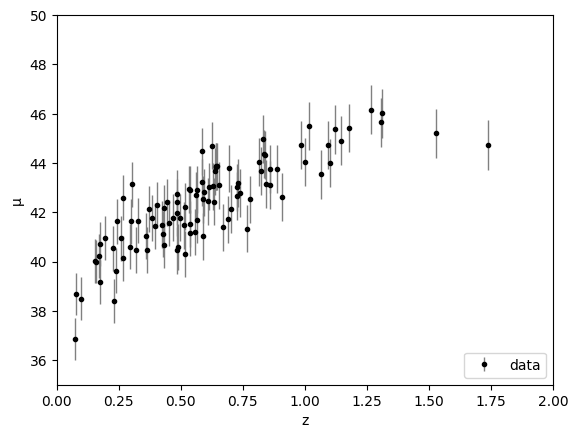

In [ ]:
from matplotlib import pyplot as plt
from astroML.datasets import generate_mu_z
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234) ###YOU CAN'T CHANGE THIS

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel("μ")
plt.legend(loc='lower right')
plt.xlim(0,2)
plt.ylim(35,50);

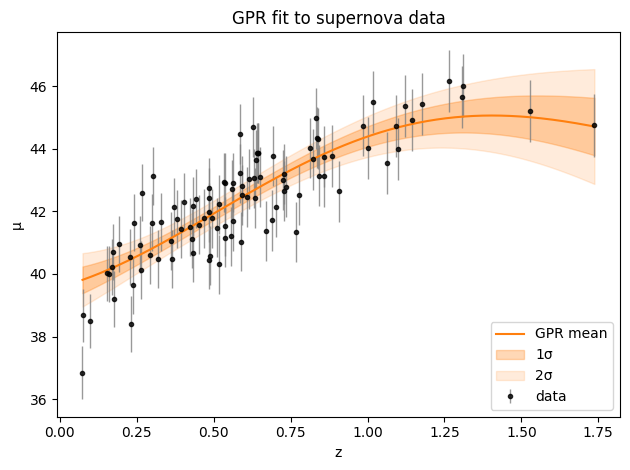

In [8]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
import numpy as np
from sklearn.preprocessing import StandardScaler
X = z_sample.reshape(-1, 1)

y = mu_sample.copy()
alpha = dmu**2                       # observational variance

# 1.4  Optional: standardise z to zero mean / unit variance
scaler_z = StandardScaler()
X_scaled = scaler_z.fit_transform(X)
kernel = RBF(length_scale=1.0)
gpr = GaussianProcessRegressor(kernel=kernel, alpha=alpha, normalize_y=True)
gpr.fit(X_scaled, y)
z_grid = np.linspace(z_sample.min(), z_sample.max(), 500).reshape(-1, 1)
z_grid_scaled = scaler_z.transform(z_grid)
y_pred, y_std = gpr.predict(z_grid_scaled, return_std=True)


plt.errorbar(z_sample, mu_sample, dmu, fmt=".k", ecolor="gray", lw=1, alpha=0.8, label='data')
plt.plot(z_grid, y_pred, color='C1', label='GPR mean')
plt.fill_between(z_grid.ravel(), y_pred - y_std, y_pred + y_std, color='C1', alpha=0.3, label='1σ')
plt.fill_between(z_grid.ravel(), y_pred - 2*y_std, y_pred + 2*y_std, color='C1', alpha=0.15, label='2σ')
plt.xlabel("z")
plt.ylabel("μ")
plt.title("GPR fit to supernova data")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()